In [4]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt

con = sqlite3.connect("../data/lottery_star.db")

In [30]:
# --- Load all Powerball numbers (each draw_id has 6 numbers: 5 main + 1 bonus) ---
df_powerball = pd.read_sql("""
SELECT f.draw_date, f.number, f.position, f.game_id
FROM fact_set_numbers f
JOIN dim_game g USING (game_id)
WHERE LOWER(g.game_name) = 'powerball'
ORDER BY f.draw_date, f.number;
""", con)

df_powerball["draw_date"] = pd.to_datetime(df_powerball["draw_date"])
df_powerball.head()


,draw_date,number,position,game_id
0,2010-02-03,17,1,2
1,2010-02-03,22,2,2
2,2010-02-03,36,3,2
3,2010-02-03,37,4,2
4,2010-02-03,52,5,2


In [32]:
# Rank numbers within each draw
df_powerball["rank_in_draw"] = df_powerball.groupby("game_id")["number"].rank(method="first")

# 6th number → bonus ball
main = df_powerball[df_powerball["rank_in_draw"] <= 5]
bonus = df_powerball[df_powerball["rank_in_draw"] == 6]

In [34]:
freq_main = main["number"].value_counts().sort_index()
freq_bonus = bonus["number"].value_counts().sort_index()

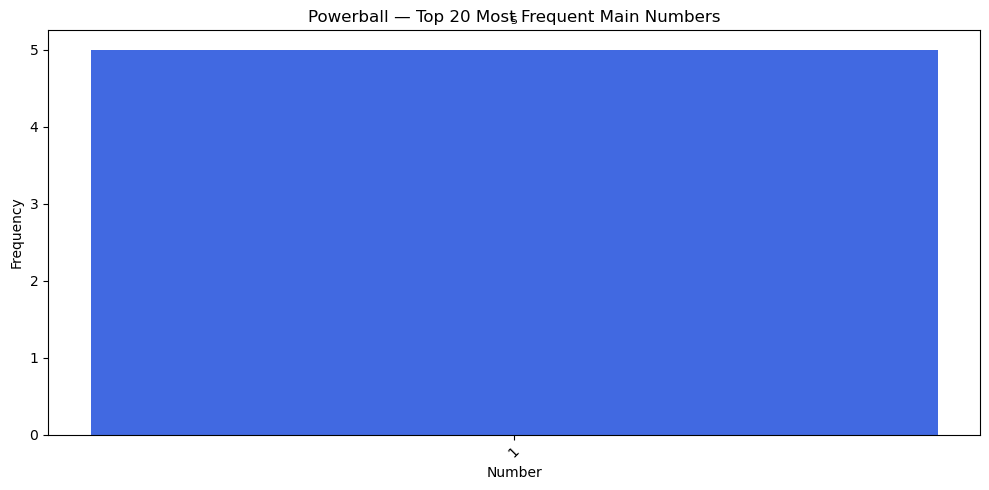

In [36]:
freq_main = main["number"].value_counts().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
bars = plt.bar(freq_main.index.astype(str), freq_main.values, color="royalblue")
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{int(b.get_height())}",
             ha="center", va="bottom", fontsize=8)
plt.title("Powerball — Top 20 Most Frequent Main Numbers")
plt.xlabel("Number")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
df = pd.read_sql("""
SELECT draw_date, number, position
FROM fact_set_numbers
JOIN dim_game USING (game_id)
WHERE game_name = 'powerball'
""", con)

df["draw_date"] = pd.to_datetime(df["draw_date"], errors="coerce")

pos_df = df.pivot(index='draw_date', columns='position', values='number')
pos_df.columns = [f"pos{i}" for i in pos_df.columns]

pos_df = pos_df.sort_index()            # just to be safe
print(type(pos_df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


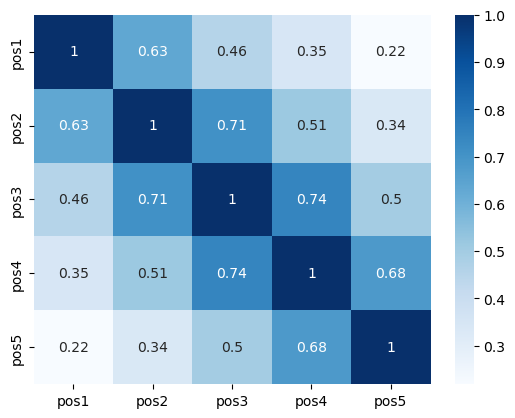

In [61]:
import seaborn as sns
sns.heatmap(pos_df.corr(), annot=True, cmap="Blues")
plt.show()


In [63]:
bonus = pd.read_sql("""
SELECT f.draw_date, f.bonus
FROM fact_set_draws f
JOIN dim_game USING (game_id)
WHERE LOWER(game_name) = 'powerball'
ORDER BY f.draw_date;
""", con)

bonus["draw_date"] = pd.to_datetime(bonus["draw_date"])
bonus["bonus"] = pd.to_numeric(bonus["bonus"], errors="coerce")
bonus.head()



,draw_date,bonus
0,2010-02-03,24
1,2010-02-06,4
2,2010-02-10,34
3,2010-02-13,1
4,2010-02-17,15


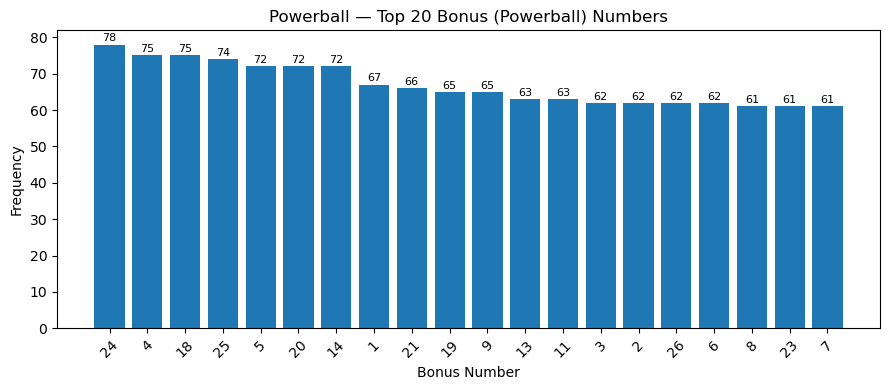

In [69]:
# Bonus frequency per number (top 20)
freq_bonus = bonus["bonus"].value_counts().sort_values(ascending=False).head(20)

plt.figure(figsize=(9,4))
bars = plt.bar(freq_bonus.index.astype(str), freq_bonus.values)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h+0.3, f"{int(h)}",
             ha="center", va="bottom", fontsize=8)
plt.title("Powerball — Top 20 Bonus (Powerball) Numbers")
plt.xlabel("Bonus Number")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [44]:
for i in range(1,6):
    freq = df[df["position"]==i]["number"].value_counts().sort_values(ascending=False)
    print(f"\n--- Position {i}: Top 10 Hot Numbers ---")
    display(freq.head(10))
    
    print(f"\n--- Position {i}: Coldest 10 Numbers ---")
    display(freq.tail(10))



--- Position 1: Top 10 Hot Numbers ---


number
1     140
2     127
3     125
5     112
4     111
8      92
6      91
7      90
9      83
10     77
Name: count, dtype: int64


--- Position 1: Coldest 10 Numbers ---


number
38    4
44    2
41    2
48    1
50    1
43    1
49    1
51    1
52    1
47    1
Name: count, dtype: int64


--- Position 2: Top 10 Hot Numbers ---


...

number
16    9
68    7
17    6
18    4
13    3
14    3
15    3
12    3
9     1
7     1
Name: count, dtype: int64


--- Position 5: Top 10 Hot Numbers ---


number
69    109
59     96
58     94
67     85
68     84
57     76
64     76
54     71
56     71
62     71
Name: count, dtype: int64


--- Position 5: Coldest 10 Numbers ---


number
29    6
35    5
30    5
20    3
24    3
26    3
23    3
19    1
25    1
22    1
Name: count, dtype: int64

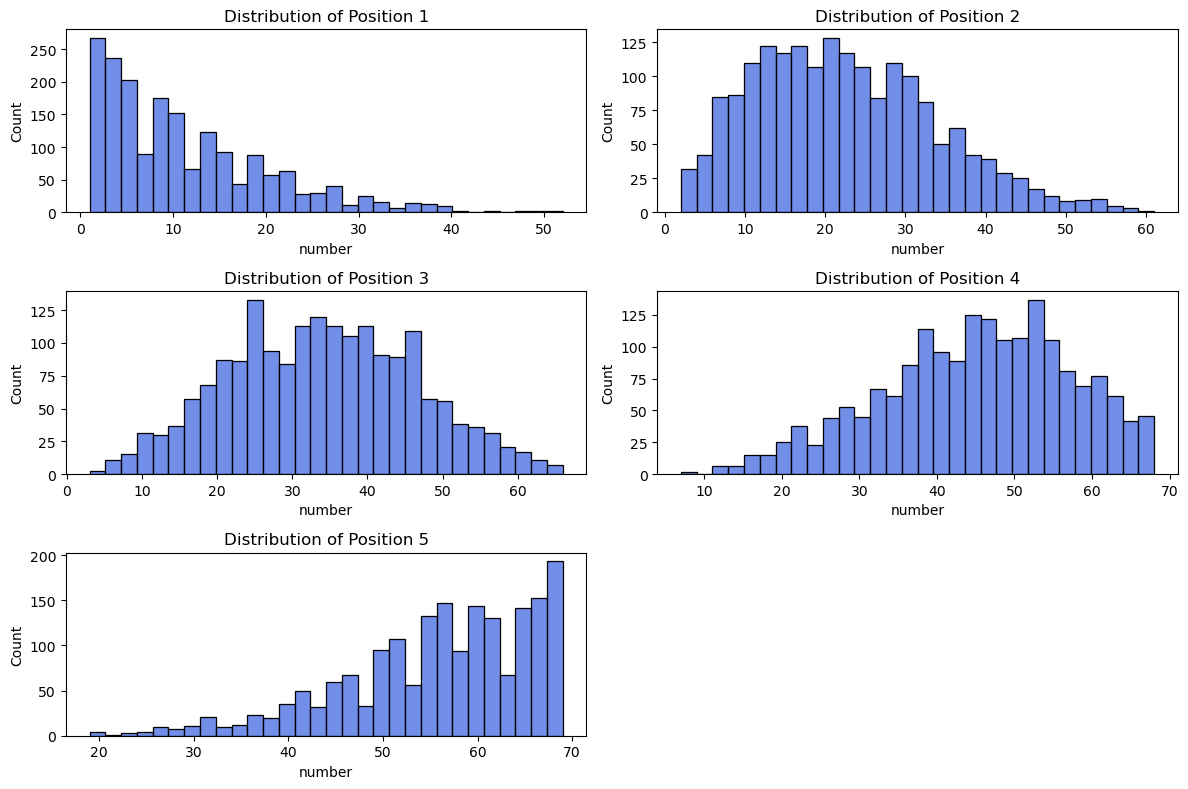

In [46]:
plt.figure(figsize=(12,8))
for i in range(1,6):
    plt.subplot(3,2,i)
    sns.histplot(df[df["position"]==i]["number"], bins=30, color="royalblue")
    plt.title(f"Distribution of Position {i}")
plt.tight_layout()
plt.show()


C:\Users\Gurram Yashaswi\AppData\Local\Temp\ipykernel_2852\2725846233.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  mean_trends = pos_df.resample("Y").mean()


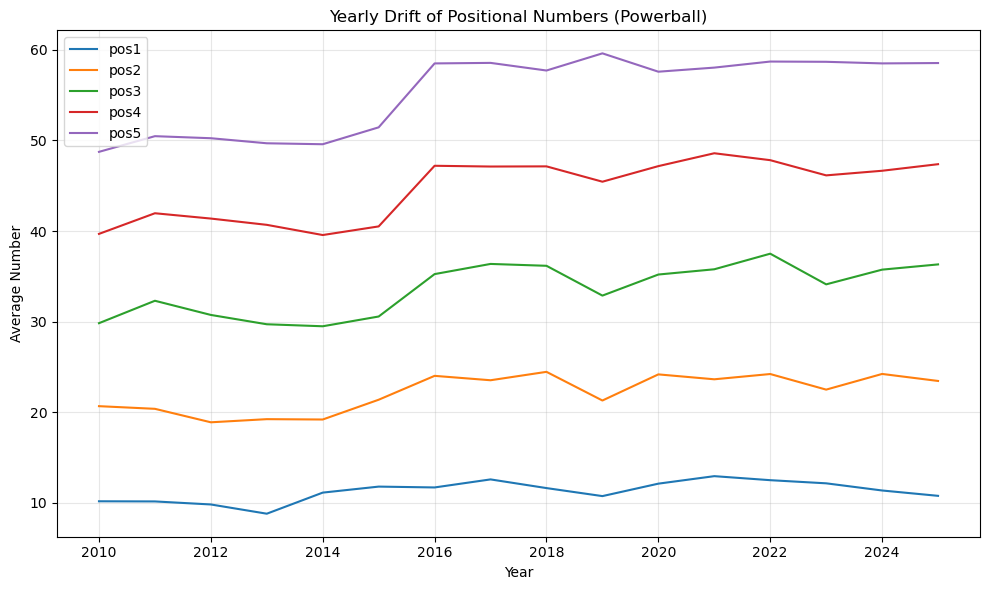

In [75]:
# Convert again to be safe
pos_df.index = pd.to_datetime(pos_df.index, errors="coerce")

mean_trends = pos_df.resample("Y").mean()

plt.figure(figsize=(10,6))
for col in mean_trends.columns:
    plt.plot(mean_trends.index.year, mean_trends[col], label=col)

plt.title("Yearly Drift of Positional Numbers (Powerball)")
plt.xlabel("Year")
plt.ylabel("Average Number")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [53]:
ml_df = pos_df.copy()

# Feature 1: lag features
for lag in range(1,8):
    for i in range(1,6):
        ml_df[f"pos{i}_lag{lag}"] = ml_df[f"pos{i}"].shift(lag)

# Feature 2: moving averages
for i in range(1,6):
    ml_df[f"pos{i}_ma10"] = ml_df[f"pos{i}"].rolling(10).mean()
    ml_df[f"pos{i}_ma50"] = ml_df[f"pos{i}"].rolling(50).mean()

# Feature 3: rolling std dev
for i in range(1,6):
    ml_df[f"pos{i}_std10"] = ml_df[f"pos{i}"].rolling(10).std()

# Feature 4: normalized positions (0–1 scale)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
ml_df[[f"pos{i}_scaled" for i in range(1,6)]] = scaler.fit_transform(pos_df)

ml_df.head()


,pos1,pos2,pos3,pos4,pos5,pos1_lag1,pos2_lag1,pos3_lag1,pos4_lag1,pos5_lag1,...,pos1_std10,pos2_std10,pos3_std10,pos4_std10,pos5_std10,pos1_scaled,pos2_scaled,pos3_scaled,pos4_scaled,pos5_scaled
draw_date,,,,,,,,,,,,,,,,,,,,,
2010-02-03,17,22,36,37,52,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.313725,0.338983,0.523810,0.491803,0.66
2010-02-06,14,22,52,54,59,17.0,22.0,36.0,37.0,52.0,...,NaN,NaN,NaN,NaN,NaN,0.254902,0.338983,0.777778,0.770492,0.80
2010-02-10,5,8,29,37,38,14.0,22.0,52.0,54.0,59.0,...,NaN,NaN,NaN,NaN,NaN,0.078431,0.101695,0.412698,0.491803,0.38
2010-02-13,10,14,30,40,51,5.0,8.0,29.0,37.0,38.0,...,NaN,NaN,NaN,NaN,NaN,0.176471,0.203390,0.428571,0.540984,0.64
2010-02-17,7,8,19,26,36,10.0,14.0,30.0,40.0,51.0,...,NaN,NaN,NaN,NaN,NaN,0.117647,0.101695,0.253968,0.311475,0.34


C:\Users\Gurram Yashaswi\AppData\Local\Temp\ipykernel_2852\1492575438.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  bonus_yearly_mean = bonus_ts["bonus"].resample("Y").mean()


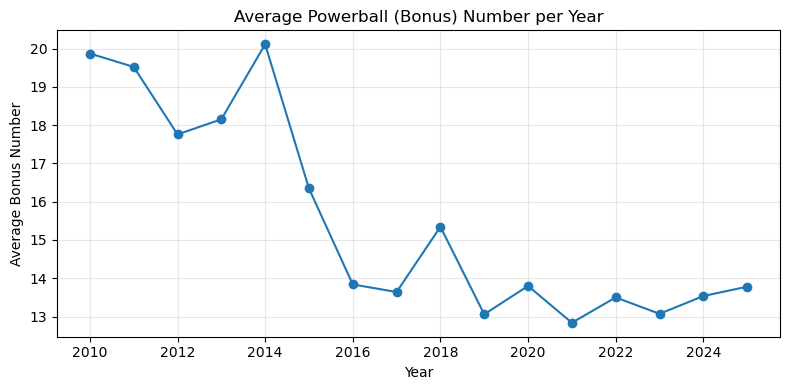

In [71]:
bonus_ts = bonus.set_index("draw_date").sort_index()
bonus_yearly_mean = bonus_ts["bonus"].resample("Y").mean()

plt.figure(figsize=(8,4))
plt.plot(bonus_yearly_mean.index.year, bonus_yearly_mean.values, marker="o")
plt.title("Average Powerball (Bonus) Number per Year")
plt.xlabel("Year")
plt.ylabel("Average Bonus Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


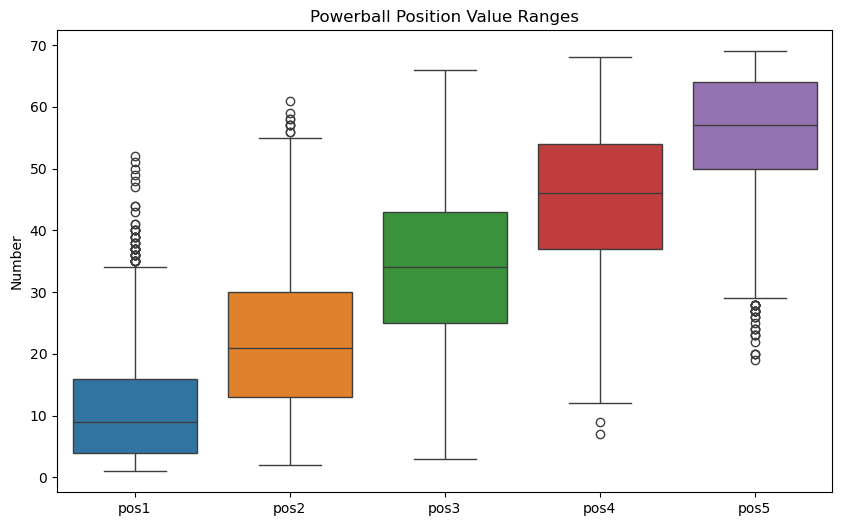

In [77]:
plt.figure(figsize=(10,6))
sns.boxplot(data=pos_df)
plt.title("Powerball Position Value Ranges")
plt.ylabel("Number")
plt.show()


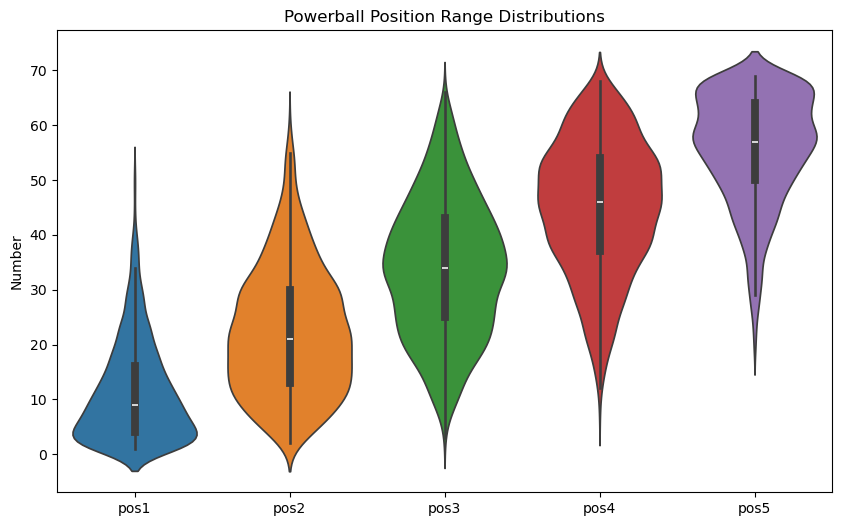

In [79]:
plt.figure(figsize=(10,6))
sns.violinplot(data=pos_df)
plt.title("Powerball Position Range Distributions")
plt.ylabel("Number")
plt.show()


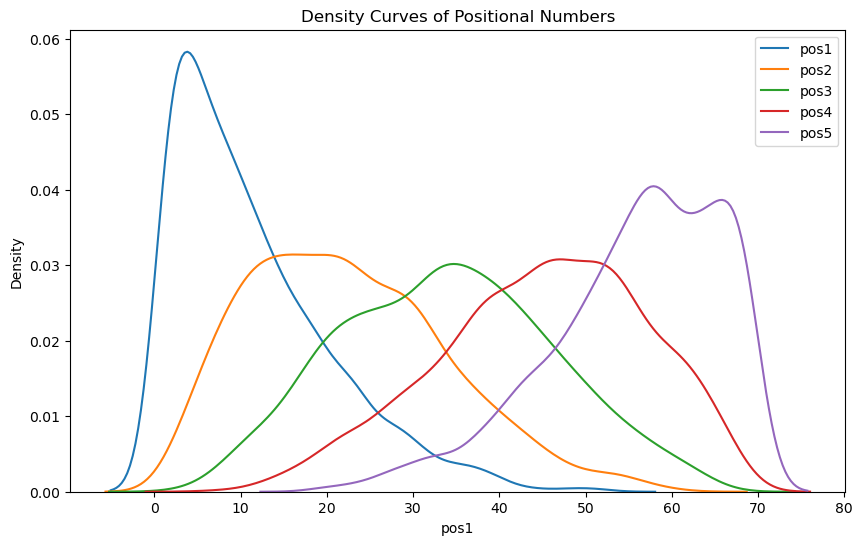

In [81]:
plt.figure(figsize=(10,6))
for i in range(1,6):
    sns.kdeplot(pos_df[f"pos{i}"], label=f"pos{i}")
plt.title("Density Curves of Positional Numbers")
plt.legend()
plt.show()


In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_sql("""
SELECT
    draw_date,
    MAX(CASE WHEN position=1 THEN number END) AS pos1,
    MAX(CASE WHEN position=2 THEN number END) AS pos2,
    MAX(CASE WHEN position=3 THEN number END) AS pos3,
    MAX(CASE WHEN position=4 THEN number END) AS pos4,
    MAX(CASE WHEN position=5 THEN number END) AS pos5
FROM fact_set_numbers f
JOIN dim_game g USING (game_id)
WHERE LOWER(g.game_name)='powerball'
GROUP BY draw_date
ORDER BY draw_date;
""", con)

df["draw_date"] = pd.to_datetime(df["draw_date"])
df.head()

,draw_date,pos1,pos2,pos3,pos4,pos5
0,2010-02-03,17,22,36,37,52
1,2010-02-06,14,22,52,54,59
2,2010-02-10,5,8,29,37,38
3,2010-02-13,10,14,30,40,51
4,2010-02-17,7,8,19,26,36


In [91]:
X = df[["pos1","pos2","pos3","pos4","pos5"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


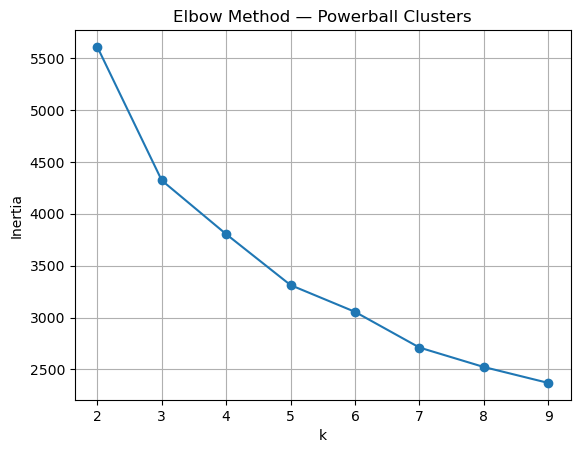

In [93]:
inertia = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker="o")
plt.title("Elbow Method — Powerball Clusters")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [95]:
k = 5
km = KMeans(n_clusters=k, random_state=42)
df["cluster"] = km.fit_predict(X_scaled)
df.head()


,draw_date,pos1,pos2,pos3,pos4,pos5,cluster
0,2010-02-03,17,22,36,37,52,2
1,2010-02-06,14,22,52,54,59,4
2,2010-02-10,5,8,29,37,38,0
3,2010-02-13,10,14,30,40,51,1
4,2010-02-17,7,8,19,26,36,0


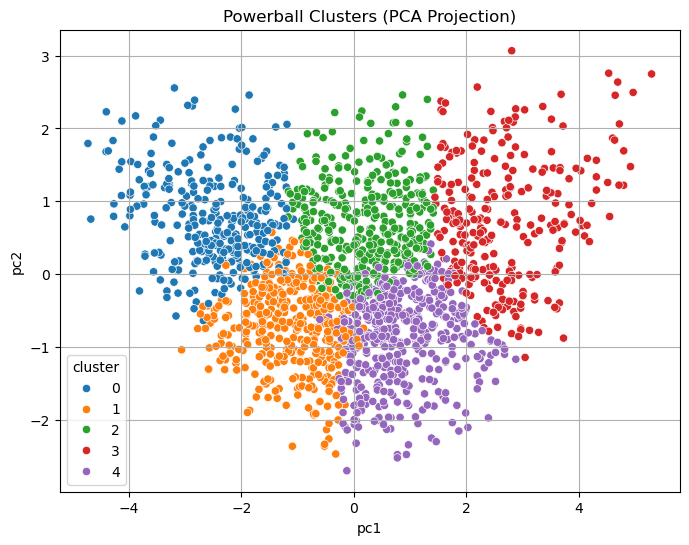

In [97]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled)

df["pc1"] = pc[:,0]
df["pc2"] = pc[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="cluster", palette="tab10")
plt.title("Powerball Clusters (PCA Projection)")
plt.grid(True)
plt.show()


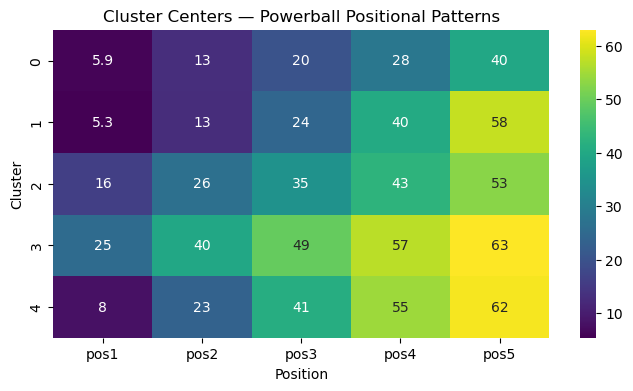

In [101]:
plt.figure(figsize=(8,4))
sns.heatmap(centers, annot=True, cmap="viridis")
plt.title("Cluster Centers — Powerball Positional Patterns")
plt.xlabel("Position")
plt.ylabel("Cluster")
plt.show()
